<a href="https://colab.research.google.com/github/luisrodriguezh-crypto/PCA-y-sistema-de-recomendaci-n/blob/main/PCA_Explicado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Análisis de Componentes Principales (PCA)

El **Análisis de Componentes Principales (PCA)** es una de las técnicas de reducción de dimensionalidad más influyentes en ciencia de datos y aprendizaje automático. Aunque métodos más recientes como **t-SNE** y **UMAP** dominan la visualización de datos complejos, PCA sigue siendo indispensable: es rápido, interpretable y matemáticamente elegante.

### ¿Cuál es el problema que resuelve?

Imagina que tienes un conjunto de datos con 30 variables. Visualizarlas todas a la vez es imposible, y trabajar con tantas dimensiones introduce ruido, redundancia y costo computacional. PCA ofrece una solución: encontrar un conjunto reducido de nuevas variables —llamadas **componentes principales**— que capturen la mayor parte de la información relevante de los datos originales.

### ¿Cómo funciona?

PCA busca las direcciones del espacio en las que los datos **varían más**. Formalmente, busca vectores $w$ (direcciones) que maximicen la varianza de los datos proyectados:

$$
\max_{w} \quad \mathrm{Var}(Xw) \qquad \text{sujeto a} \quad \|w\| = 1
$$

Este problema de optimización conduce directamente a un **problema de autovalores** sobre la matriz de covarianza $\Sigma$:

$$
\Sigma w = \lambda w
$$

donde:
- $\Sigma$ es la matriz de covarianza de los datos,
- $\lambda$ es el **autovalor** (eigenvalue), que representa la varianza capturada por esa dirección,
- $w$ es el **autovector** (eigenvector), que define la dirección del componente principal.

Los componentes se ordenan de mayor a menor varianza explicada. Además, cada componente es **ortogonal** al anterior, lo que garantiza que no capturen información redundante:

$$
w_1^\top w_2 = 0
$$

### ¿Cuántos componentes necesito?

Al retener solo $k$ componentes, podemos cuantificar qué fracción de la varianza total conservamos:

$$
\text{Varianza explicada} = \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{i=1}^{d} \lambda_i}
$$

En la práctica, suele ser posible capturar el 80–95% de la varianza con una fracción pequeña de los componentes originales.

### ¿Por qué aprender PCA hoy?

Aunque t-SNE y UMAP son más poderosos para visualización no lineal, PCA sigue siendo ampliamente utilizado como paso de **preprocesamiento**, para **reducir ruido**, **acelerar el entrenamiento** de modelos, y como **base conceptual** para entender métodos más avanzados como PCA Kernel, Autoencoders y Análisis de Factores.


---
## 1. Importación de librerías


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficas
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')


---
## 2. Dataset: Breast Cancer Wisconsin

Para este análisis utilizaremos el dataset **Breast Cancer Wisconsin**, incluido en `scikit-learn`. No requiere descarga externa y es ampliamente usado como referencia en benchmarks de clasificación binaria.

### Descripción

El dataset proviene de imágenes digitalizadas de biopsias de tejido mamario. A partir de cada imagen se extraen características numéricas que describen la morfología de los núcleos celulares: tamaño, forma, textura y regularidad, entre otras.

La tarea consiste en clasificar cada muestra como tumor **maligno** o **benigno**, basándose en estas características.

El dataset contiene:

| Atributo | Valor |
|---|---|
| Número de muestras | 569 |
| Número de características | 30 (numéricas, continuas) |
| Clases | Maligno (0) · Benigno (1) |

Este dataset es especialmente adecuado para explorar PCA porque sus 30 variables están **altamente correlacionadas** entre sí —por ejemplo, el radio, el perímetro y el área de una célula se mueven juntos—, lo que significa que existe redundancia significativa que PCA puede eliminar sin perder información relevante.


In [29]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='clase')

print('Dataset')
print(f'   - Número de muestras: {X.shape[0]}')
print(f'   - Número de características: {X.shape[1]}')
print(f'   - Clases: {data.target_names}')

Dataset
   - Número de muestras: 569
   - Número de características: 30
   - Clases: ['malignant' 'benign']


### 2.1 Revisión del dataset

Antes de aplicar cualquier técnica, es fundamental explorar los datos: verificar su estructura, detectar valores faltantes y comprender la distribución de las clases.


In [30]:
# Ver las primeras filas
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [31]:
print('Estadísticas descriptivas:')
X.describe()

Estadísticas descriptivas:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [32]:
# Verificar valores nulos
nulos = X.isnull().sum().sum()
print(f' Valores nulos en el dataset: {nulos}')

# Distribución de clases
print('\n Distribución de clases:')
conteo = y.value_counts()
for idx, count in conteo.items():
    nombre = data.target_names[idx]
    print(f'   - {nombre} (clase {idx}): {count} muestras ({count/len(y)*100:.1f}%)')

 Valores nulos en el dataset: 0

 Distribución de clases:
   - benign (clase 1): 357 muestras (62.7%)
   - malignant (clase 0): 212 muestras (37.3%)


### 2.2 Distribuciones univariables por clase

Visualizamos la distribución de las primeras 6 características separada por clase (maligno vs. benigno). Esto nos permite identificar qué variables, por sí solas, ya ofrecen poder discriminativo.

Si las distribuciones de ambas clases se solapan mucho, la variable aislada no es suficiente para clasificar. Si están bien separadas, puede ser un buen predictor individual.


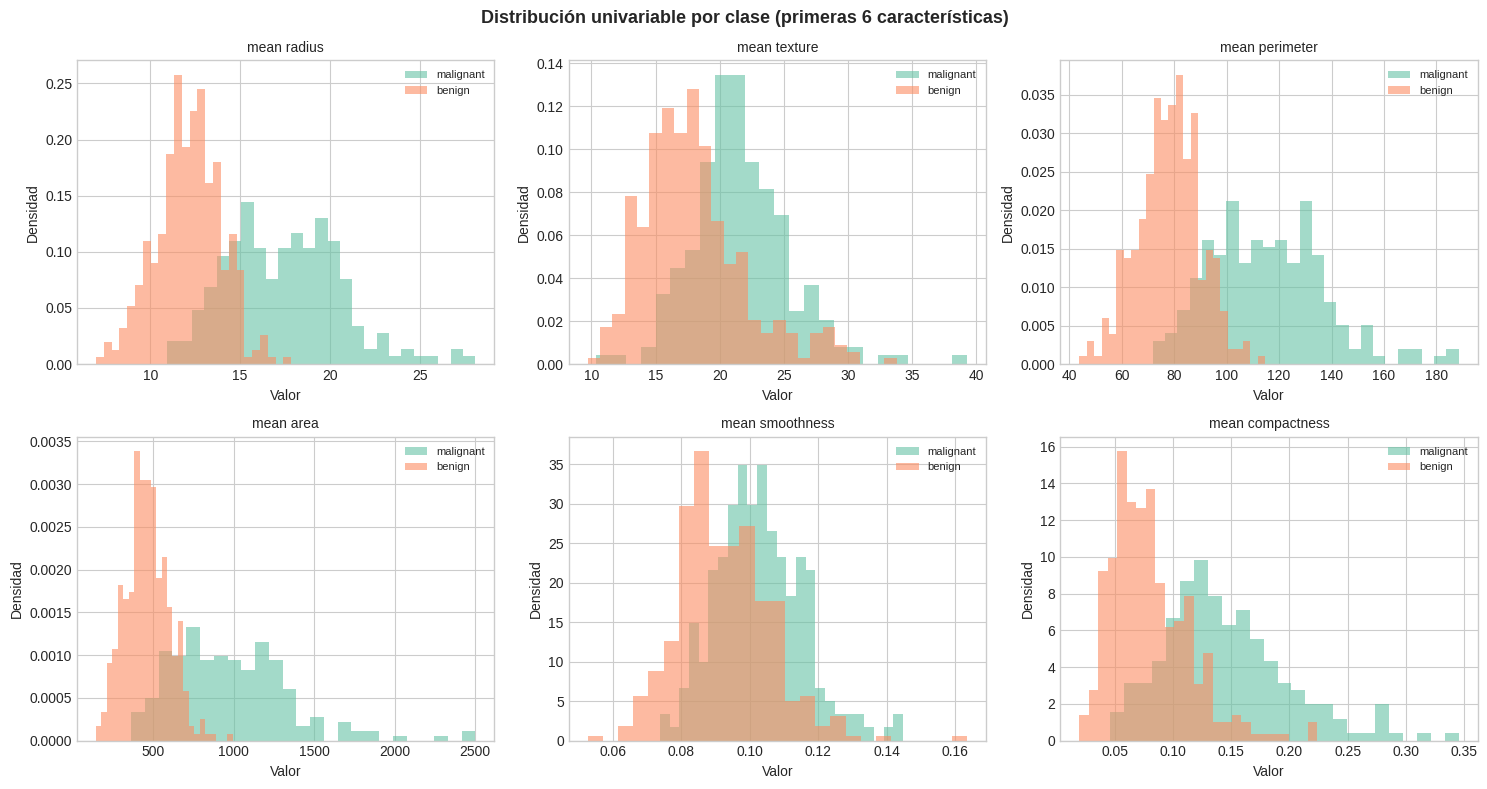

Interpretación: Algunas características ya muestran separación entre clases.
   Sin embargo, con 30 variables necesitamos una estrategia más eficiente.


In [33]:
# Gráficas de densidad para las primeras 6 características
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(X.columns[:6]):
    for clase in [0, 1]:
        mask = y == clase
        axes[i].hist(X.loc[mask, feature], alpha=0.6, bins=25,
                     label=data.target_names[clase], density=True)
    axes[i].set_title(feature, fontsize=10)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Densidad')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución univariable por clase (primeras 6 características)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Interpretación: Algunas características ya muestran separación entre clases.\n'
      '   Sin embargo, con 30 variables necesitamos una estrategia más eficiente.')

### 2.3 Relación bivariable entre características

Exploramos la relación entre dos características a la vez mediante un diagrama de dispersión. Aunque las clases pueden separarse en el espacio bidimensional original, veremos más adelante que PCA puede encontrar proyecciones **mucho más informativas** que cualquier par de variables originales.


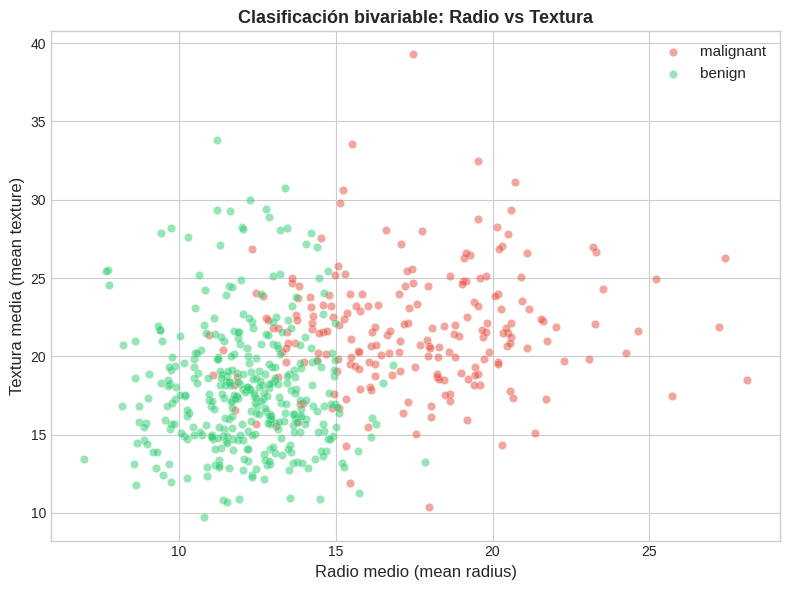

 Interpretación: Hay cierta separación, pero las clases se traslapan.
   Con solo 2 variables no tenemos toda la información necesaria.


In [34]:
# Gráfica de dispersión bivariable (primeras 2 características)
fig, ax = plt.subplots(figsize=(8, 6))

colores = ['#e74c3c', '#2ecc71']
for clase in [0, 1]:
    mask = y == clase
    ax.scatter(X.loc[mask, 'mean radius'], X.loc[mask, 'mean texture'],
               alpha=0.5, label=data.target_names[clase],
               color=colores[clase], edgecolor='white', linewidth=0.3)

ax.set_xlabel('Radio medio (mean radius)', fontsize=12)
ax.set_ylabel('Textura media (mean texture)', fontsize=12)
ax.set_title('Clasificación bivariable: Radio vs Textura', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(' Interpretación: Hay cierta separación, pero las clases se traslapan.\n'
      '   Con solo 2 variables no tenemos toda la información necesaria.')

---
## 3. Preprocesamiento

### 3.1 División en entrenamiento y prueba

Dividimos el dataset antes de cualquier transformación para simular un escenario realista donde los datos de prueba son **completamente desconocidos** durante el entrenamiento. Usamos una proporción 70/30:

- **70% entrenamiento** → para ajustar el escalador y el modelo
- **30% prueba** → para evaluar el rendimiento en datos no vistos

El parámetro `stratify=y` garantiza que ambas particiones mantengan la misma proporción de clases que el dataset original.


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f' División completada:')
print(f'   - Entrenamiento: {X_train.shape[0]} muestras')
print(f'   - Prueba:        {X_test.shape[0]} muestras')

 División completada:
   - Entrenamiento: 398 muestras
   - Prueba:        171 muestras


### 3.2 Estandarización de variables

PCA es sensible a la escala de las variables. Si una variable tiene valores en el orden de los miles (por ejemplo, área en µm²) y otra en décimas (por ejemplo, fractal dimension), PCA le asignará automáticamente mayor importancia a la primera —no porque sea más informativa, sino simplemente porque tiene mayor varianza bruta.

Para evitar este sesgo, estandarizamos cada variable de modo que tenga **media 0** y **desviación estándar 1**:

$$z = \frac{x - \mu}{\sigma}$$

**Regla clave:** el escalador se **ajusta únicamente con los datos de entrenamiento** y luego se aplica con los mismos parámetros a los datos de prueba. Ajustarlo también con el conjunto de prueba constituiría una *fuga de información* (*data leakage*) que inflaría artificialmente el rendimiento del modelo.


In [36]:
scaler = StandardScaler()

# Ajustar con entrenamiento, transformar ambos conjuntos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f' Estandarización completada')
print(f'   - Media en train (primeras 3 columnas): {X_train_scaled[:, :3].mean(axis=0).round(4)}')
print(f'   - Std  en train (primeras 3 columnas): {X_train_scaled[:, :3].std(axis=0).round(4)}')

 Estandarización completada
   - Media en train (primeras 3 columnas): [-0.  0.  0.]
   - Std  en train (primeras 3 columnas): [1. 1. 1.]


---
## 4. Modelo base (sin PCA)

Antes de aplicar PCA, entrenamos una **Regresión Logística** con las 30 características originales. Este modelo servirá como **línea base** (*baseline*): si PCA conserva la información relevante, los modelos entrenados con pocos componentes deberían aproximarse a estas métricas.

Evaluamos el rendimiento con tres métricas complementarias:

| Métrica | Descripción |
|---|---|
| **Accuracy** | Proporción de predicciones correctas sobre el total |
| **F1 Score** | Media armónica de precisión y sensibilidad; más robusta ante clases desbalanceadas |
| **AUC-ROC** | Área bajo la curva ROC; mide la capacidad del modelo para separar las clases a distintos umbrales de decisión |


In [37]:
# Modelo de regresión logística sin PCA
lr_base = LogisticRegression(max_iter=5000, random_state=42)
lr_base.fit(X_train_scaled, y_train)

y_pred_base = lr_base.predict(X_test_scaled)
y_prob_base = lr_base.predict_proba(X_test_scaled)[:, 1]

acc_base = accuracy_score(y_test, y_pred_base)
f1_base  = f1_score(y_test, y_pred_base)
auc_base = roc_auc_score(y_test, y_prob_base)

print('Resultados del modelo BASE (sin PCA, 30 características):')
print(f'   - Accuracy : {acc_base:.4f}')
print(f'   - F1 Score : {f1_base:.4f}')
print(f'   - AUC-ROC  : {auc_base:.4f}')
print()
print(classification_report(y_test, y_pred_base, target_names=data.target_names))

Resultados del modelo BASE (sin PCA, 30 características):
   - Accuracy : 0.9883
   - F1 Score : 0.9907
   - AUC-ROC  : 0.9981

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        64
      benign       0.99      0.99      0.99       107

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



---
## 5. Aplicación de PCA

### 5.1 Visualización del dataset estandarizado

Antes de aplicar PCA, graficamos el dataset estandarizado como un mapa de calor. Cada fila representa una observación y cada columna una característica. Esto nos da una primera intuición de la estructura de los datos: si hay patrones de color visibles, es señal de que existe estructura latente que PCA puede capturar.


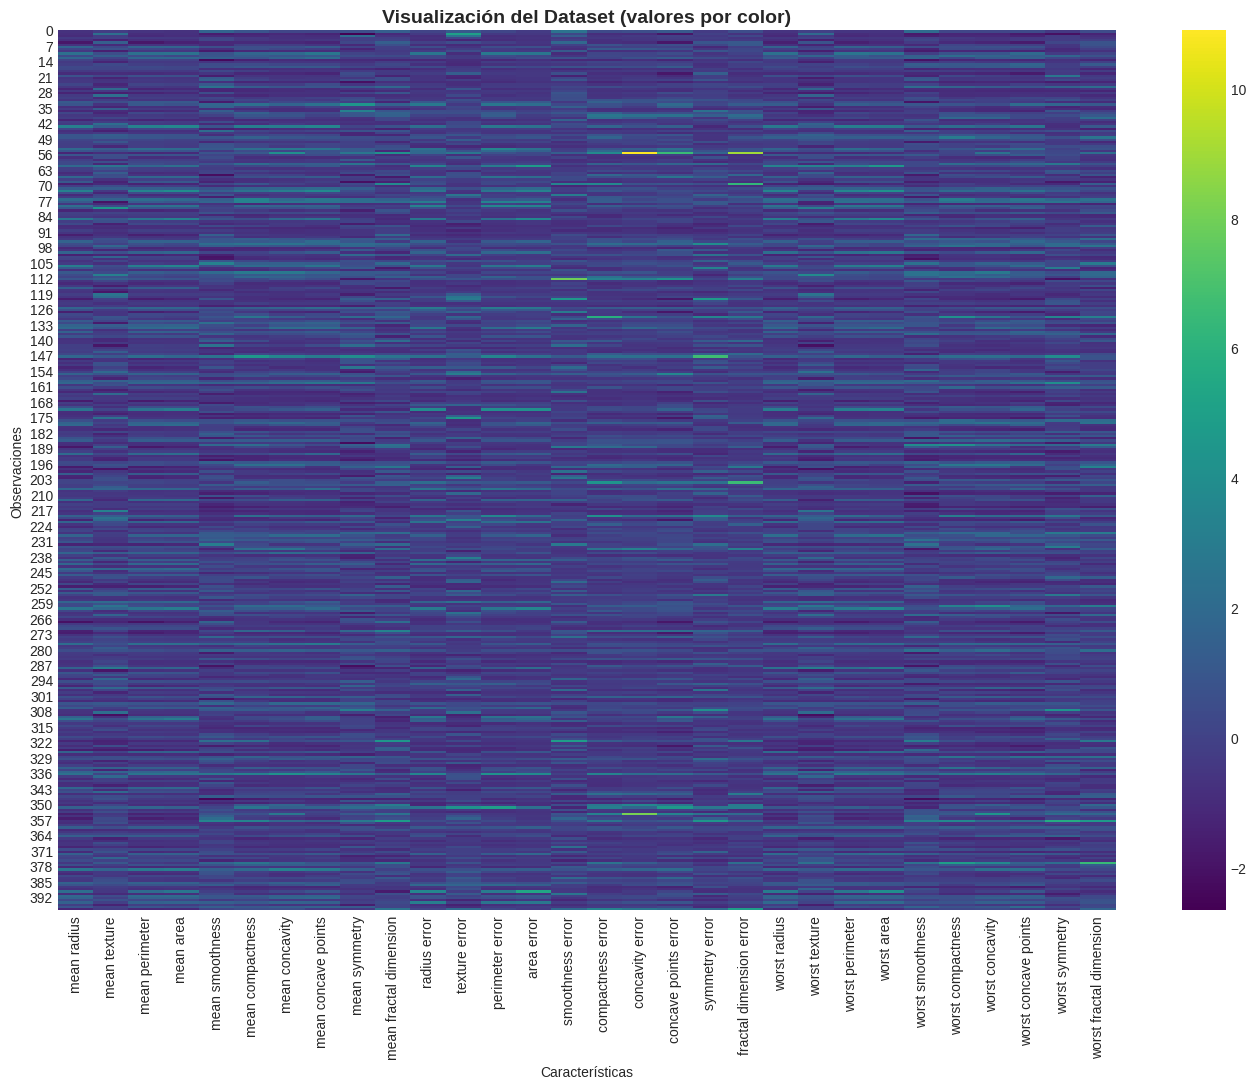

In [38]:
# Heatmap de los datos reales (no correlación)
df_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)

fig, ax = plt.subplots(figsize=(14, 11))

sns.heatmap(df_train_scaled, cmap='viridis', ax=ax, cbar=True)

ax.set_title('Visualización del Dataset (valores por color)', fontsize=14, fontweight='bold')
ax.set_xlabel('Características')
ax.set_ylabel('Observaciones')

plt.tight_layout()
plt.show()

### 5.2 Varianza explicada y Scree Plot

Para decidir cuántos componentes principales conservar, analizamos cuánta varianza captura cada uno.

La **Proporción de Varianza Explicada (PVE)** del $k$-ésimo componente se define como:

$$PVE_k = \frac{\lambda_k}{\sum_{j=1}^{p} \lambda_j}$$

donde $\lambda_k$ es el autovalor del $k$-ésimo componente principal.

Dos herramientas visuales nos ayudan a elegir $k$:

- **Scree Plot**: grafica la PVE de cada componente en orden decreciente. Buscamos el punto de *codo*, donde la curva se aplana, lo que indica que los componentes adicionales aportan poca información nueva.
- **Varianza acumulada**: muestra qué porcentaje de la varianza total se acumula al agregar componentes. Permite determinar cuántos necesitamos para alcanzar un umbral deseado (p. ej., 90%).


In [39]:
# PCA completo para analizar varianza
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

pve = pca_full.explained_variance_ratio_
pve_acumulada = np.cumsum(pve)

# Encontrar componentes necesarios para distintos umbrales
umbrales = [0.60, 0.70, 0.80, 0.90, 0.95]
print(' Componentes necesarios por umbral de varianza acumulada:')
for umbral in umbrales:
    n = np.argmax(pve_acumulada >= umbral) + 1
    print(f'   - {int(umbral*100)}% de varianza → {n} componentes principales')

 Componentes necesarios por umbral de varianza acumulada:
   - 60% de varianza → 2 componentes principales
   - 70% de varianza → 3 componentes principales
   - 80% de varianza → 4 componentes principales
   - 90% de varianza → 7 componentes principales
   - 95% de varianza → 10 componentes principales


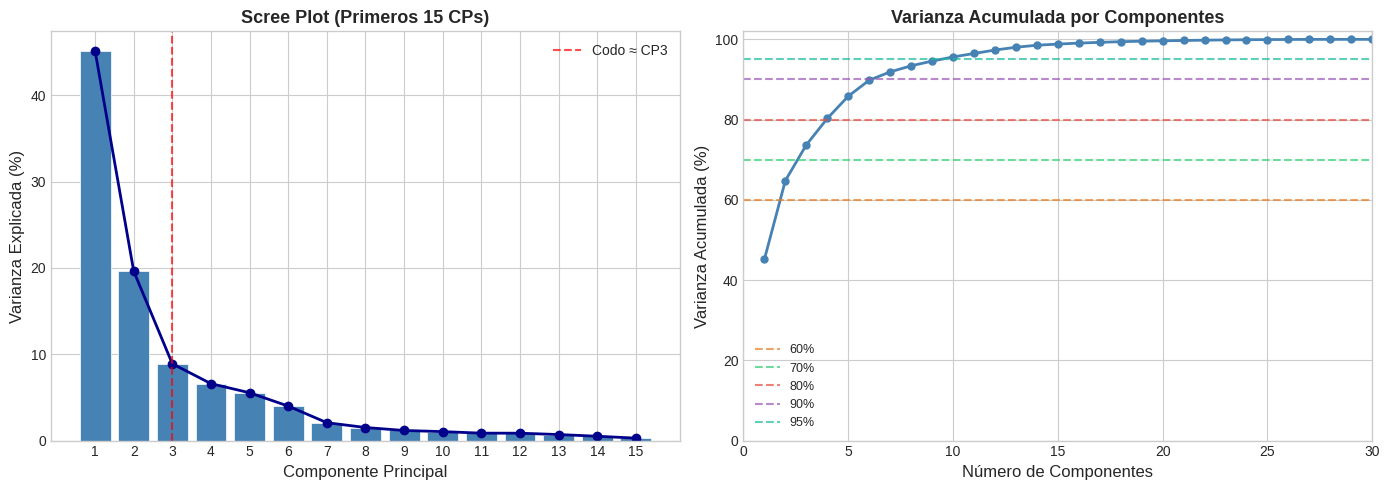

💡 El scree plot muestra un "codo" alrededor del CP3, lo que sugiere que
   los primeros 3 componentes capturan la mayor parte de la varianza relevante.
   La varianza acumulada ayuda a decidir con más precisión cuántos conservar.


In [40]:
# Visualización: Scree Plot + Varianza Acumulada
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Scree Plot ---
ax1.bar(range(1, 16), pve[:15] * 100, color='steelblue', edgecolor='white', linewidth=0.5)
ax1.plot(range(1, 16), pve[:15] * 100, 'o-', color='darkblue', linewidth=2, markersize=6)
ax1.set_xlabel('Componente Principal', fontsize=12)
ax1.set_ylabel('Varianza Explicada (%)', fontsize=12)
ax1.set_title('Scree Plot (Primeros 15 CPs)', fontsize=13, fontweight='bold')
ax1.set_xticks(range(1, 16))

# Marcar el codo aproximado
ax1.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Codo ≈ CP3')
ax1.legend()

# --- Varianza acumulada ---
ax2.plot(range(1, len(pve_acumulada) + 1), pve_acumulada * 100,
         'o-', color='steelblue', linewidth=2, markersize=5)
ax2.axhline(y=60, color='#e67e22', linestyle='--', alpha=0.7, label='60%')
ax2.axhline(y=70, color='#2ecc71', linestyle='--', alpha=0.7, label='70%')
ax2.axhline(y=80, color='#e74c3c', linestyle='--', alpha=0.7, label='80%')
ax2.axhline(y=90, color='#9b59b6', linestyle='--', alpha=0.7, label='90%')
ax2.axhline(y=95, color='#1abc9c', linestyle='--', alpha=0.7, label='95%')
ax2.set_xlabel('Número de Componentes', fontsize=12)
ax2.set_ylabel('Varianza Acumulada (%)', fontsize=12)
ax2.set_title('Varianza Acumulada por Componentes', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_ylim(0, 102)
ax2.set_xlim(0, 30)

plt.tight_layout()
plt.show()

print('💡 El scree plot muestra un "codo" alrededor del CP3, lo que sugiere que\n'
      '   los primeros 3 componentes capturan la mayor parte de la varianza relevante.\n'
      '   La varianza acumulada ayuda a decidir con más precisión cuántos conservar.')

---
## 6. Comparación de modelos con distintos números de componentes

Ahora evaluamos el impacto de la reducción de dimensionalidad sobre el rendimiento predictivo. Entrenamos una Regresión Logística para cada valor de $k$ (número de componentes principales) y comparamos las métricas resultantes con el modelo base de 30 variables.

Si PCA está funcionando correctamente, deberíamos observar que con $k$ relativamente pequeño —y por lo tanto con una fracción de la información original— el modelo mantiene un rendimiento comparable al baseline.


In [41]:
# Iterar sobre distintas cantidades de componentes
resultados = []
n_componentes_list = [2, 3, 5, 7, 10, 15, 20, 25, 30]

for n in n_componentes_list:
    # Aplicar PCA
    pca = PCA(n_components=n, random_state=42)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca  = pca.transform(X_test_scaled)

    # Entrenar modelo
    lr = LogisticRegression(max_iter=5000, random_state=42)
    lr.fit(X_train_pca, y_train)

    # Evaluar
    y_pred = lr.predict(X_test_pca)
    y_prob = lr.predict_proba(X_test_pca)[:, 1]

    varianza_total = pca.explained_variance_ratio_.sum() * 100

    resultados.append({
        'N° Componentes': n,
        'Varianza Explicada (%)': round(varianza_total, 2),
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1 Score': round(f1_score(y_test, y_pred), 4),
        'AUC-ROC': round(roc_auc_score(y_test, y_prob), 4)
    })

# Modelo base (30 características originales)
resultados.append({
    'N° Componentes': '30 (original)',
    'Varianza Explicada (%)': 100.0,
    'Accuracy': round(acc_base, 4),
    'F1 Score': round(f1_base, 4),
    'AUC-ROC': round(auc_base, 4)
})

df_resultados = pd.DataFrame(resultados)
df_resultados

,N° Componentes,Varianza Explicada (%),Accuracy,F1 Score,AUC-ROC
0,2,64.78,0.9474,0.9581,0.9924
1,3,73.68,0.9298,0.9444,0.9882
2,5,85.82,0.9766,0.9813,0.9968
3,7,91.89,0.9591,0.9668,0.9956
4,10,95.62,0.9708,0.9763,0.9980
5,15,98.82,0.9708,0.9763,0.9981
6,20,99.63,0.9883,0.9907,0.9981
7,25,99.95,0.9883,0.9907,0.9981
8,30,100.00,0.9883,0.9907,0.9981
9,30 (original),100.00,0.9883,0.9907,0.9981


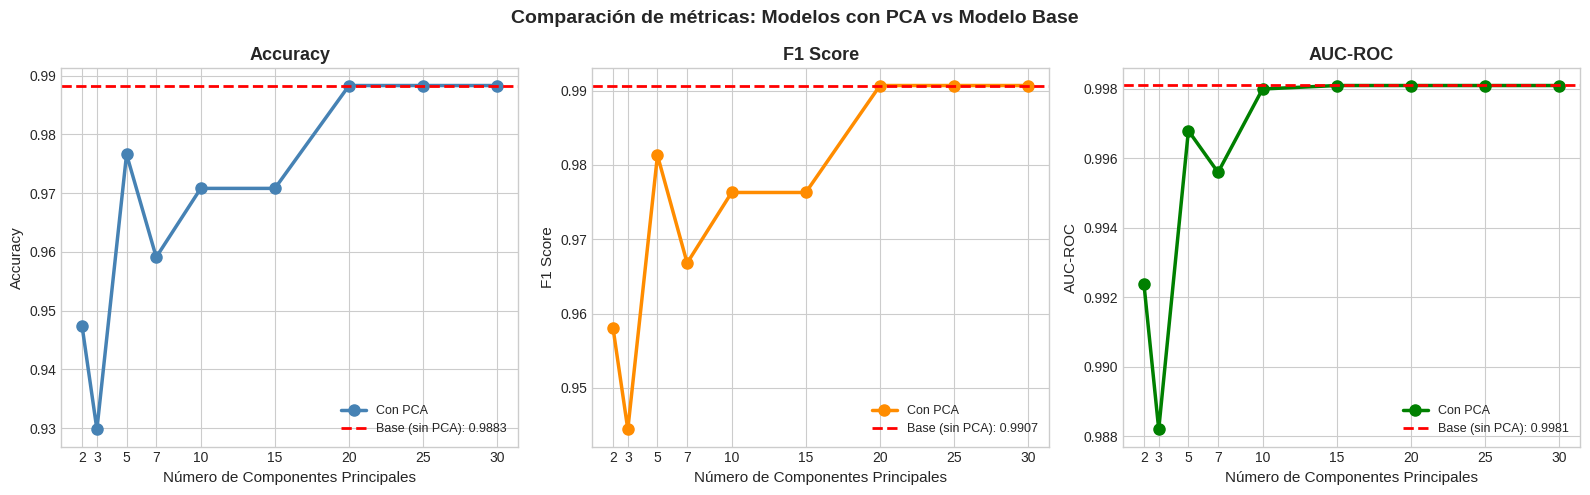

💡 Interpretación: Con pocos componentes (ej. 7-10) podemos obtener métricas
   muy similares al modelo completo, con mucho menor dimensionalidad.


In [42]:
# Visualizar comparación de métricas
df_plot = df_resultados[df_resultados['N° Componentes'] != '30 (original)'].copy()
df_plot['N° Componentes'] = df_plot['N° Componentes'].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metricas = ['Accuracy', 'F1 Score', 'AUC-ROC']
colores_linea = ['steelblue', 'darkorange', 'green']
valores_base = [acc_base, f1_base, auc_base]

for i, (metrica, color, val_base) in enumerate(zip(metricas, colores_linea, valores_base)):
    axes[i].plot(df_plot['N° Componentes'], df_plot[metrica],
                 'o-', color=color, linewidth=2.5, markersize=8, label='Con PCA')
    axes[i].axhline(y=val_base, color='red', linestyle='--',
                    linewidth=2, label=f'Base (sin PCA): {val_base:.4f}')
    axes[i].set_xlabel('Número de Componentes Principales', fontsize=11)
    axes[i].set_ylabel(metrica, fontsize=11)
    axes[i].set_title(metrica, fontsize=13, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].set_xticks(df_plot['N° Componentes'])

plt.suptitle('Comparación de métricas: Modelos con PCA vs Modelo Base',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Interpretación: Con pocos componentes (ej. 7-10) podemos obtener métricas\n'
      '   muy similares al modelo completo, con mucho menor dimensionalidad.')

---
## 7. Correlación antes y después de PCA

Una propiedad matemática fundamental de PCA es que los componentes principales resultantes son **ortogonales entre sí**, lo que implica que están **perfectamente incorrelacionados**.

En contraste, las variables originales suelen presentar correlaciones fuertes entre sí —especialmente en este dataset, donde medidas geométricas como radio, perímetro y área están intrínsecamente relacionadas.

Esta sección compara la matriz de correlación del espacio original con la del espacio transformado por PCA, evidenciando la eliminación de la redundancia lineal entre variables.


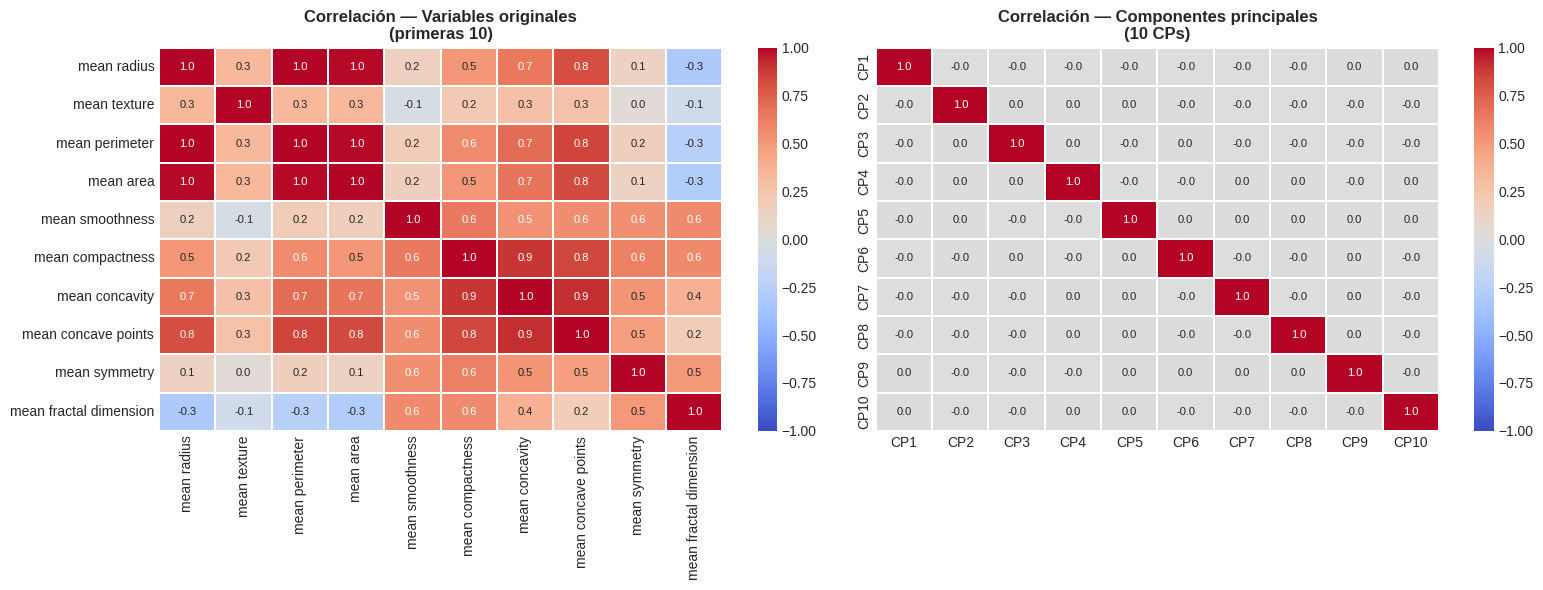

In [43]:
# PCA con 10 componentes para el heatmap
pca_10 = PCA(n_components=10, random_state=42)
X_train_pca10 = pca_10.fit_transform(X_train_scaled)

nombres_cp = [f'CP{i+1}' for i in range(10)]
df_pca = pd.DataFrame(X_train_pca10, columns=nombres_cp)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap original (primeras 10 variables para comparar)
corr_orig_10 = df_train_scaled.iloc[:, :10].corr()
sns.heatmap(corr_orig_10, cmap='coolwarm', center=0, ax=ax1,
            vmin=-1, vmax=1, linewidths=0.3, annot=True, fmt='.1f', annot_kws={'size': 8})
ax1.set_title('Correlación — Variables originales\n(primeras 10)', fontsize=12, fontweight='bold')

# Heatmap PCA
corr_pca = df_pca.corr()
sns.heatmap(corr_pca, cmap='coolwarm', center=0, ax=ax2,
            vmin=-1, vmax=1, linewidths=0.3, annot=True, fmt='.1f', annot_kws={'size': 8})
ax2.set_title('Correlación — Componentes principales\n(10 CPs)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()



---
## 8. Proyección en 2D con PCA

Una de las aplicaciones más intuitivas de PCA es la **visualización de datos de alta dimensión**. Al conservar únicamente los dos primeros componentes principales, obtenemos la proyección bidimensional que **maximiza la varianza** de los datos —es decir, la que preserva mejor la estructura global del dataset.

Esto es cualitativamente diferente a simplemente tomar dos variables originales al azar: PCA encuentra las dos *direcciones más informativas* del espacio de 30 dimensiones.


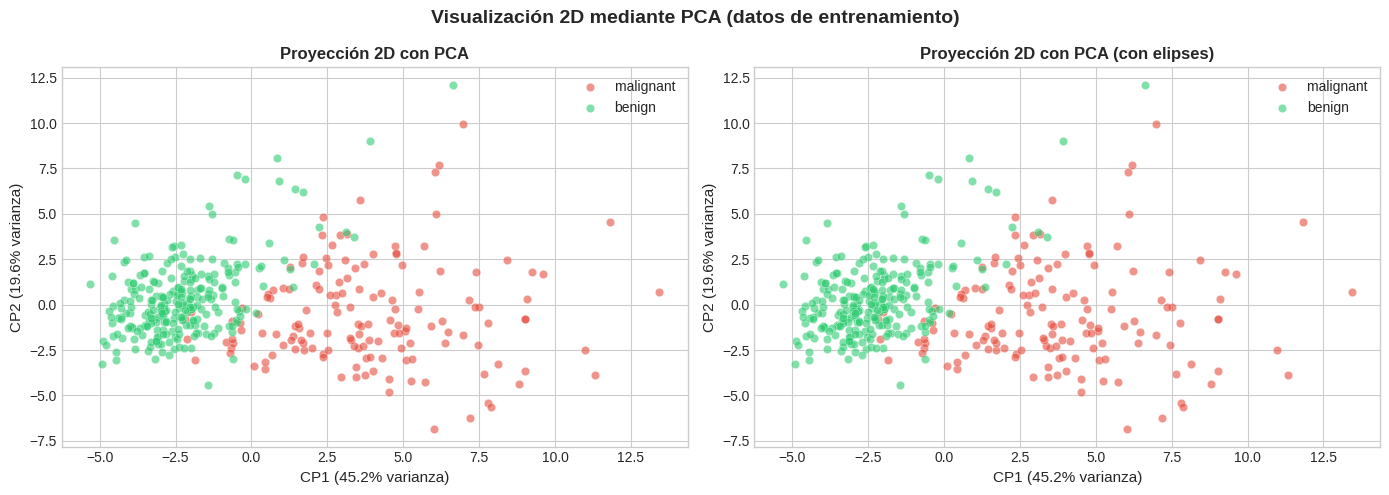

💡 Con solo 2 componentes capturamos el 64.8% de la varianza total.
   Las clases se separan notablemente bien en este espacio reducido.


In [44]:
# PCA con 2 componentes para visualización
pca_2 = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2.fit_transform(X_train_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores = ['#e74c3c', '#2ecc71']
for ax_idx, (ax, title) in enumerate(zip(axes,
    ['Proyección 2D con PCA', 'Proyección 2D con PCA (con elipses)'])):

    for clase in [0, 1]:
        mask = y_train.values == clase
        ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                   alpha=0.6, label=data.target_names[clase],
                   color=colores[clase], edgecolor='white', linewidth=0.3)

    ax.set_xlabel(f'CP1 ({pca_2.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=11)
    ax.set_ylabel(f'CP2 ({pca_2.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)

plt.suptitle('Visualización 2D mediante PCA (datos de entrenamiento)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'💡 Con solo 2 componentes capturamos el '
      f'{(pca_2.explained_variance_ratio_.sum()*100):.1f}% de la varianza total.\n'
      f'   Las clases se separan notablemente bien en este espacio reducido.')

---
## 9. Interpretación de los componentes: Cargas (Loadings)

Una limitación frecuentemente citada de PCA es que los componentes principales son difíciles de interpretar, ya que son combinaciones lineales de todas las variables originales. Sin embargo, al analizar las **cargas** (*loadings*), podemos identificar qué variables dominan cada componente y asignarle un significado aproximado.

Las cargas son los elementos de la matriz $W$ (autovectores de $\Sigma$). Para cada componente $k$ y variable $j$:

- $w_{jk} > 0$ grande → la variable $j$ crece en la dirección del CP$k$
- $w_{jk} < 0$ grande → la variable $j$ decrece en esa dirección
- $|w_{jk}| \approx 0$ → la variable $j$ no contribuye significativamente al CP$k$

En el contexto de este dataset, si CP1 tiene cargas altas en radio, perímetro y área, podemos interpretarlo como un **"factor de tamaño tumoral"**.


In [50]:
# Obtener cargas del PCA completo
pca_interp = PCA(n_components=5, random_state=42)
pca_interp.fit(X_train_scaled)

loadings = pd.DataFrame(
    pca_interp.components_.T,
    index=X.columns,
    columns=[f'CP{i+1}' for i in range(5)]
)

print('Cargas de los primeros 5 componentes principales:')
loadings.round(3)

Cargas de los primeros 5 componentes principales:


,CP1,CP2,CP3,CP4,CP5
mean radius,0.217,-0.232,0.001,-0.046,-0.034
mean texture,0.096,-0.073,0.172,0.581,-0.006
mean perimeter,0.225,-0.213,-0.002,-0.046,-0.033
mean area,0.220,-0.227,0.023,-0.055,-0.006
mean smoothness,0.139,0.182,-0.179,-0.066,0.353
mean compactness,0.239,0.145,-0.078,-0.008,-0.022
mean concavity,0.254,0.073,-0.008,-0.018,-0.092
mean concave points,0.259,-0.033,-0.047,-0.055,0.043
mean symmetry,0.139,0.195,-0.061,-0.051,0.298
mean fractal dimension,0.068,0.361,-0.035,-0.021,0.022


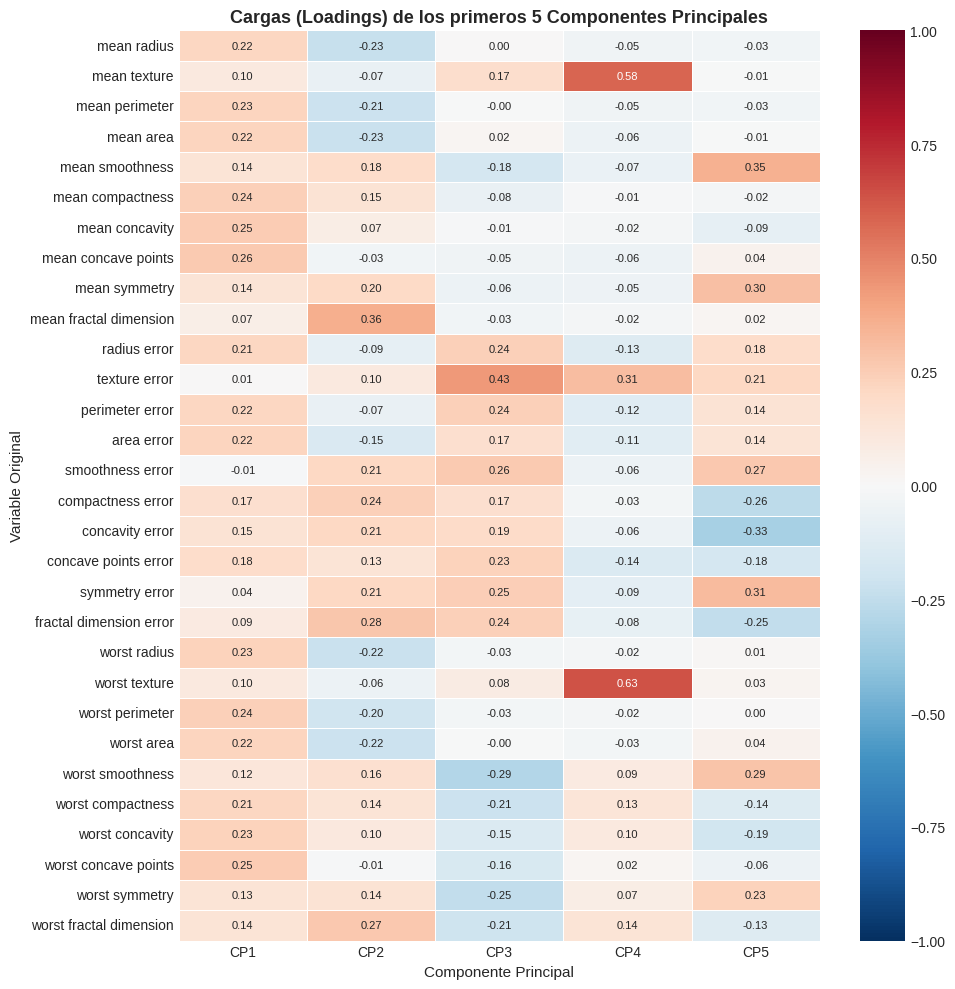

In [46]:
# Heatmap de cargas
fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    loadings,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.4,
    ax=ax,
    vmin=-1,
    vmax=1,
    annot_kws={'size': 8}
)
ax.set_title('Cargas (Loadings) de los primeros 5 Componentes Principales',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Componente Principal', fontsize=11)
ax.set_ylabel('Variable Original', fontsize=11)
plt.tight_layout()
plt.show()

In [47]:
for cp in ['CP1', 'CP2']:
    top5 = loadings[cp].abs().nlargest(5)
    print(f'\n Top 5 variables con mayor influencia en {cp}:')
    for var, val in top5.items():
        signo = '+' if loadings.loc[var, cp] > 0 else '-'
        print(f'   {signo} {var}: {loadings.loc[var, cp]:.3f}')


 Top 5 variables con mayor influencia en CP1:
   + mean concave points: 0.259
   + mean concavity: 0.254
   + worst concave points: 0.250
   + mean compactness: 0.239
   + worst perimeter: 0.235

 Top 5 variables con mayor influencia en CP2:
   + mean fractal dimension: 0.361
   + fractal dimension error: 0.279
   + worst fractal dimension: 0.269
   + compactness error: 0.236
   - mean radius: -0.232


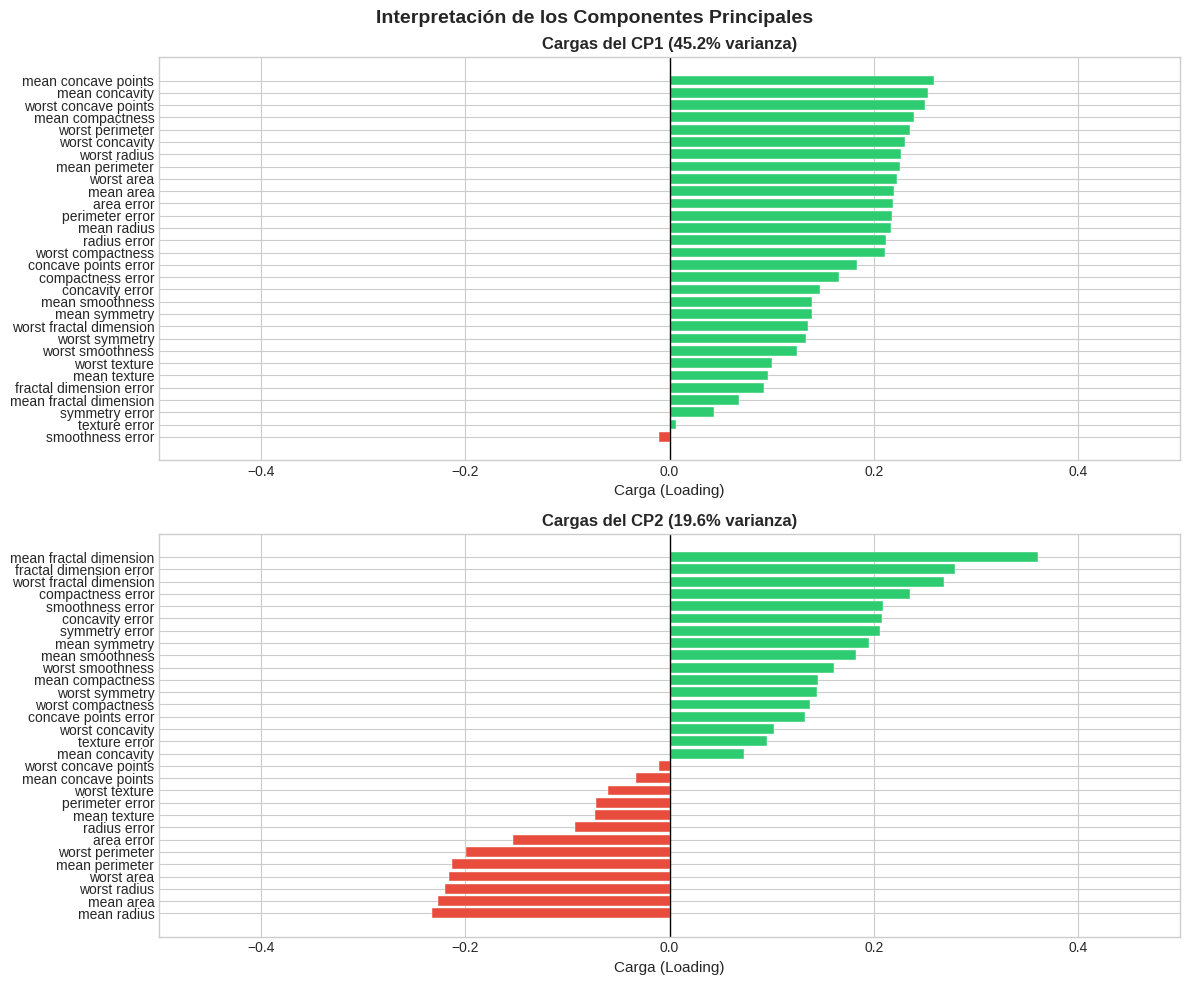

 CP1 está dominado por variables de tamaño (radio, perímetro, área).
   CP2 mezcla otras características como textura y simetría.
   Esto da una interpretación geométrica/médica a los componentes.


In [48]:
# Gráfica de barras para los loadings del CP1
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

for ax, cp in zip([ax1, ax2], ['CP1', 'CP2']):
    datos_cp = loadings[cp].sort_values()
    colores_barras = ['#e74c3c' if v < 0 else '#2ecc71' for v in datos_cp]
    ax.barh(datos_cp.index, datos_cp.values, color=colores_barras, edgecolor='white', linewidth=0.3)
    ax.axvline(x=0, color='black', linewidth=1)
    ax.set_xlabel('Carga (Loading)', fontsize=11)
    ax.set_title(f'Cargas del {cp} ({pca_interp.explained_variance_ratio_[[int(cp[-1])-1]][0]*100:.1f}% varianza)',
                 fontsize=12, fontweight='bold')
    ax.set_xlim(-0.5, 0.5)

plt.suptitle('Interpretación de los Componentes Principales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(' CP1 está dominado por variables de tamaño (radio, perímetro, área).\n'
      '   CP2 mezcla otras características como textura y simetría.\n'
      '   Esto da una interpretación geométrica/médica a los componentes.')

---
## 10. Resumen y conclusiones

### ¿Qué aprendimos?

A lo largo de este notebook exploramos PCA de manera progresiva: primero su fundamento matemático, luego su implementación paso a paso, y finalmente su evaluación empírica.

Los resultados muestran que es posible reducir las 30 variables originales a tan solo 7–10 componentes principales y obtener un rendimiento predictivo prácticamente idéntico al modelo con todas las características. Esto tiene implicaciones prácticas importantes:

- **Menor costo computacional**: menos dimensiones implican modelos más rápidos de entrenar y más baratos de desplegar.
- **Reducción de ruido**: al descartar componentes con varianza baja, PCA puede eliminar ruido y mejorar la generalización.
- **Visualización**: los primeros 2–3 componentes permiten explorar visualmente la estructura del dataset.

### Limitaciones de PCA

- PCA asume relaciones **lineales**. Si la estructura real de los datos es no lineal, métodos como Kernel PCA, t-SNE o UMAP pueden capturar más información.
- Los componentes principales **no son directamente interpretables** como las variables originales, aunque el análisis de loadings ayuda.
- PCA **no utiliza las etiquetas** de clase; es un método no supervisado. Para reducción de dimensionalidad supervisada, existen alternativas como LDA (*Linear Discriminant Analysis*).


In [49]:
# Resumen de resultados
print('=' * 65)
print('                 RESUMEN FINAL - PCA ')
print('=' * 65)

print('\n Dataset: Breast Cancer Wisconsin')
print(f'   - 569 muestras, 30 características')
print(f'   - Tarea: clasificación binaria (maligno vs benigno)')

print('\n Comparación de modelos:')
print(f'{"Modelo":<25} {"Acc":>8} {"F1":>8} {"AUC":>8}')
print('-' * 55)
print(f'{"Base (30 vars)":<25} {acc_base:>8.4f} {f1_base:>8.4f} {auc_base:>8.4f}')

for n_comp in [5, 7, 10]:
    pca_temp = PCA(n_components=n_comp, random_state=42)
    X_tr = pca_temp.fit_transform(X_train_scaled)
    X_te = pca_temp.transform(X_test_scaled)
    lr_temp = LogisticRegression(max_iter=5000, random_state=42)
    lr_temp.fit(X_tr, y_train)
    yp = lr_temp.predict(X_te)
    yprob = lr_temp.predict_proba(X_te)[:, 1]
    var = pca_temp.explained_variance_ratio_.sum() * 100
    nombre = f'PCA-{n_comp} ({var:.0f}% var)'
    print(f'{nombre:<25} {accuracy_score(y_test, yp):>8.4f} {f1_score(y_test, yp):>8.4f} {roc_auc_score(y_test, yprob):>8.4f}')


                 RESUMEN FINAL - PCA 

 Dataset: Breast Cancer Wisconsin
   - 569 muestras, 30 características
   - Tarea: clasificación binaria (maligno vs benigno)

 Comparación de modelos:
Modelo                         Acc       F1      AUC
-------------------------------------------------------
Base (30 vars)              0.9883   0.9907   0.9981
PCA-5 (86% var)             0.9766   0.9813   0.9968
PCA-7 (92% var)             0.9591   0.9668   0.9956
PCA-10 (96% var)            0.9708   0.9763   0.9980


---

## Referencias

- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.). Springer.
- Scikit-learn Documentation: [sklearn.decomposition.PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
- Dataset: [Breast Cancer Wisconsin (Diagnostic)](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-wisconsin-dataset)

